In [70]:
import wandb
import os 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from model.nnModel import Net

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import pickle


In [71]:
# run = wandb.init(
#     # Set the wandb entity where your project will be logged (generally your team name).
#     entity="sanjana-learning",
#     # Set the wandb project where this run will be logged.
#     project="cat-or-dog",
#     # Track hyperparameters and run metadata.
#     config={
#         "architecture": "CNN",
#         "dataset": "https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/data",
#     },
#)

In [72]:
def load_data (X,y):
    X_test_data = np.load(X, allow_pickle=True)
    y_test_data = np.load(y, allow_pickle=True)

    # X should become [N, 1, 50, 50] float32
    X_test = torch.tensor(np.array(X_test_data), dtype=torch.float32)
    y_test = torch.tensor(np.array(y_test_data), dtype=torch.float32)  # [N,2]


    print("X:", X_test.shape, X_test.dtype)
    print("y:", y_test.shape, y_test.dtype, "unique:", torch.unique(y_test))
    assert len(X_test) == len(y_test)
    return X_test,y_test

In [73]:
def get_metrics(net, X, y,model):
    net.eval()
    with torch.no_grad():
        X_te = X
        logits_te = net(X_te)

        probs_pos = torch.softmax(logits_te, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(logits_te, dim=1).cpu().numpy()
        y_true = y.cpu().numpy()

        cm = confusion_matrix(y_true, preds)
        acc = accuracy_score(y_true, preds)
        prec = precision_score(y_true, preds, zero_division=0)
        rec = recall_score(y_true, preds, zero_division=0)
        f1 = f1_score(y_true, preds, zero_division=0)

        try:
            auc = roc_auc_score(y_true, probs_pos)
        except ValueError:
            auc = float("nan")

    return {"model":model,
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "auc": auc,
            "cm":cm}

In [74]:
file_path = 'data/testScores.pkl'

if not os.path.exists(file_path):
    X,y = load_data("data/catdog_X_test.npy","data/catdog_y_test.npy")

    models= []
    for filename in os.listdir('model'):
        if filename.endswith('.pth'):
            models.append('model/'+filename)
    models = sorted(models)


    device = "cuda" if torch.cuda.is_available() else "cpu"
    net = Net().to(device)
    eval_metrics = []
    for model in models: 
        #loads in weights and biases
        model_name = model.split("_")[3].split(".")[0]
        net.load_state_dict(torch.load(model))
        eval_metrics.append(get_metrics(net,X,y,model_name))

    with open(file_path, 'wb') as file:
        pickle.dump(eval_metrics, file)
        print(f"List successfully pickled to {file_path}")
else: 
    print(f"{file_path} exists, choose new file name or delete existing file")


data/testScores.pkl exists, choose new file name or delete existing file


In [75]:
# ----------
# Figures 
# ----------
file_path = 'data/testScores.pkl'
with open(file_path, 'rb') as file:
    eval_metrics = pickle.load(file)


file_path = 'data/validationScores.pkl'
with open(file_path, 'rb') as file:
    validation_scores = pickle.load(file)

In [76]:
validation_df = pd.DataFrame(validation_scores)
validation_df['subset_fold_epoch'] = validation_df.subset+"-k"+validation_df.fold.astype('str')+"e"+validation_df.epoch.astype('str')
validation_df['model'] = "k"+validation_df.fold.astype('str')+"e"+validation_df.epoch.astype('str')

train_df = validation_df[validation_df.subset == "train"]
val_df = validation_df[validation_df.subset == "val"]

test_df = pd.DataFrame(eval_metrics)

In [77]:
def create_plot(train_df, val_df, title, metric, color): 
    fig_2 = plt.figure(figsize=(16, 8))
    
    plt.plot(train_df.model, train_df[metric], label=f'{metric} (Train)', linewidth=2, linestyle='-', color=color)
    plt.plot(val_df.model, val_df[metric], label=f'{metric} (Val)', linewidth=2, linestyle='--', color=color)

    # Offsets for train and val max points
    train_offset = (5, 10)
    val_offset = (-20, -20)
    
    # Add max markers for train
    max_idx_train = train_df[metric].idxmax()
    max_val_train = train_df[metric].max()
    max_x_train = train_df.loc[max_idx_train, 'model']
    
    plt.plot(max_x_train, max_val_train, 'o', color=color, markersize=10, markeredgewidth=2, markeredgecolor='black')
    plt.annotate(f'{max_val_train:.3f}', 
                xy=(max_x_train, max_val_train), 
                xytext=train_offset,
                textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=color))
    
    # Add max markers for val
    max_idx_val = val_df[metric].idxmax()
    max_val_val = val_df[metric].max()
    max_x_val = val_df.loc[max_idx_val, 'model']
    
    plt.plot(max_x_val, max_val_val, 'o', color=color, markersize=10, markeredgewidth=2, markeredgecolor='black')
    plt.annotate(f'{max_val_val:.3f}', 
                xy=(max_x_val, max_val_val), 
                xytext=val_offset,
                textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=color))

    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim([0, 1.1])
    plt.xlim([0, 25])
    plt.xlabel("k+epoch", fontsize=14, weight='bold')
    plt.ylabel(f"{metric}", fontsize=14, weight='bold')
    plt.title(f"Cat Dog {title} Metrics", fontsize=20, weight='bold')
    plt.legend(fontsize=12, loc='lower right')
    plt.tight_layout() 
    plt.show()
    return fig_2

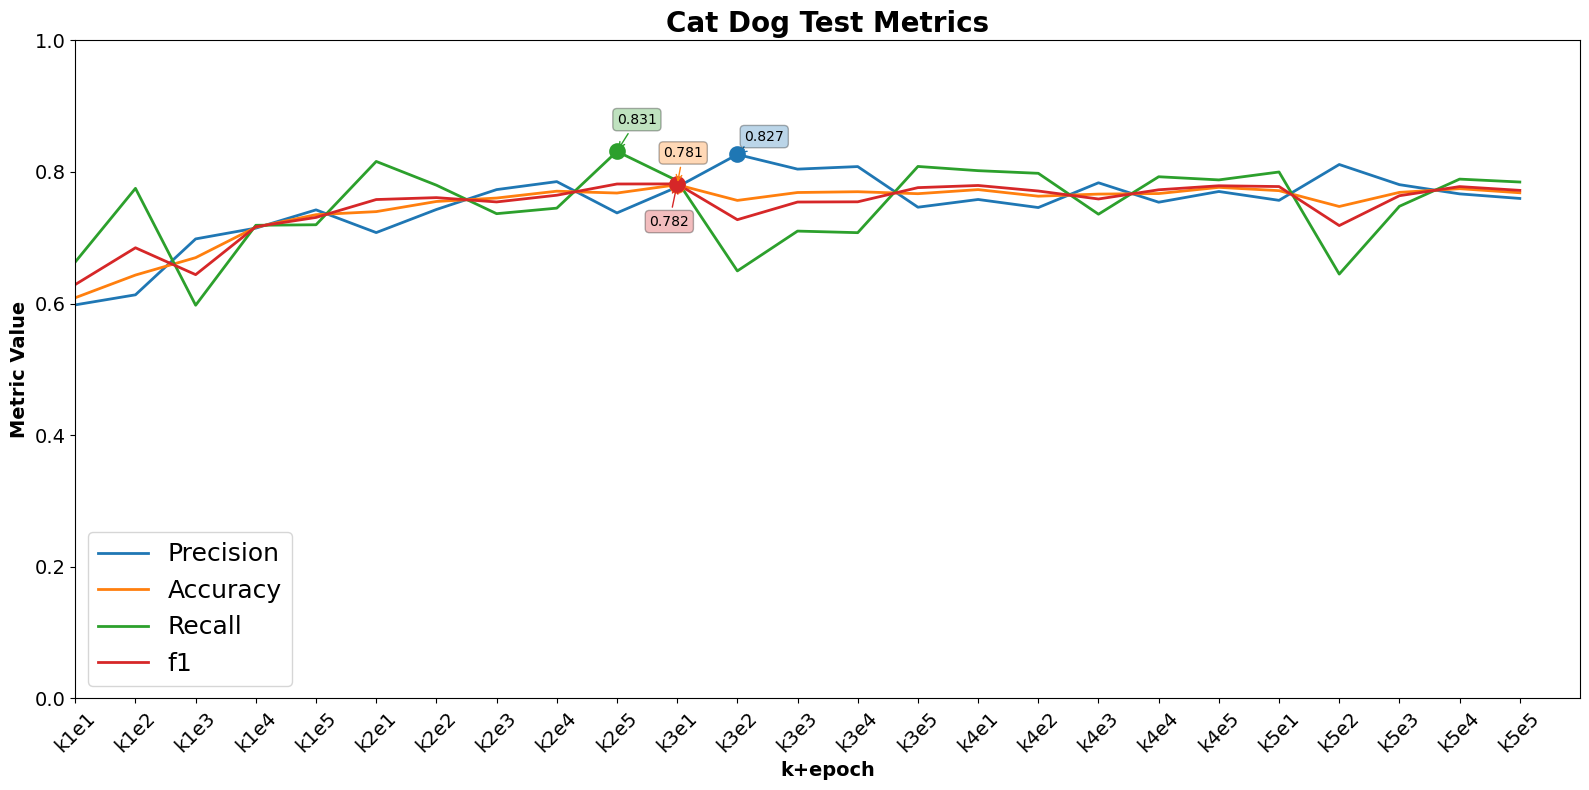

In [78]:
fig_1 = plt.figure(figsize=(16, 8))  # width=12 inches, height=6 inches
plt.plot(test_df.model, test_df.precision, label='Precision', linewidth=2)
plt.plot(test_df.model, test_df.accuracy, label='Accuracy', linewidth=2)
plt.plot(test_df.model, test_df.recall, label='Recall',linewidth=2)
plt.plot(test_df.model, test_df.f1, label='f1',linewidth=2)

metrics = ['precision', 'accuracy', 'recall', 'f1']
colors = ['C0', 'C1', 'C2', 'C3']
offsets = [(5, 10), (-10, 20), (0, 20), (-20, -30)]  # Different offsets for each

for metric, color, offset in zip(metrics, colors, offsets):
    max_idx = test_df[metric].idxmax()
    max_val = test_df[metric].max()
    max_x = max_idx
    
    # Plot a marker at the max point
    plt.plot(max_x, max_val, 'o', color=color, markersize=10, markeredgewidth=2)
    
    # Add annotation with custom offset
    plt.annotate(f'{max_val:.3f}', 
                xy=(max_x, max_val), 
                xytext=offset,  # Custom position per metric
                textcoords='offset points',
                fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3),
                #add arrow
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=color))

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.ylim([0,1])
plt.xlim([0,25])
plt.xlabel("k+epoch", fontsize=14, weight = 'bold')
plt.ylabel("Metric Value",fontsize=14, weight = 'bold')
plt.title("Cat Dog Test Metrics",fontsize=20, weight = 'bold')
plt.legend(fontsize = 18)
plt.tight_layout() 
#plt.show()


In [79]:
STOP_HERE = True

if STOP_HERE:
    print("Stopping execution")
else: 
    wandb.init(
        entity="sanjana-learning",
        project="cat-or-dog",
        config={
            "architecture": "CNN",
            "dataset": "https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset/data",
        },
    )

    f1 = create_plot(train_df, val_df, "Training vs Validation", "f1","red")
    acc = create_plot(train_df, val_df, "Training vs Validation", "accuracy","blue")
    prec = create_plot(train_df, val_df, "Training vs Validation", "precision","orange")
    rec = create_plot(train_df, val_df, "Training vs Validation", "recall","green")

    #training/validation plots 
    wandb.log({f"plots/training_validation_precision": wandb.Image(prec)})
    wandb.log({f"plots/training_validation_f1": wandb.Image(f1)})
    wandb.log({f"plots/training_validation_accuracy": wandb.Image(acc)})
    wandb.log({f"plots/training_validation_recall": wandb.Image(rec)})

    #test plot
    wandb.log({f"plots/test_metrics": wandb.Image(fig_1)})



    #wandb.log({f"plots/fold_{fold_id}": wandb.Image(g.fig)})
    wandb.finish()


Stopping execution


In [81]:
validation_df.head()

,subset,fold,epoch,train_loss,accuracy,precision,recall,f1,auc,cm,subset_fold_epoch,model
0,train,1,1,0.684803,0.622400,0.609723,0.681482,0.643609,0.667784,"[[4493, 3484], [2544, 5443]]",train-k1e1,k1e1
1,val,1,1,0.684803,0.616232,0.604865,0.662645,0.632438,0.664822,"[[1142, 861], [671, 1318]]",val-k1e1,k1e1
2,train,1,2,0.649704,0.657730,0.623737,0.796169,0.699483,0.729088,"[[4141, 3836], [1628, 6359]]",train-k1e2,k1e2
3,val,1,2,0.649704,0.644539,0.612382,0.780794,0.686409,0.715070,"[[1020, 983], [436, 1553]]",val-k1e2,k1e2
4,train,1,3,0.603405,0.697507,0.726023,0.635032,0.677486,0.770218,"[[6063, 1914], [2915, 5072]]",train-k1e3,k1e3


In [85]:
train_df[['model',"cm"]].head()

,model,cm
0,k1e1,"[[4493, 3484], [2544, 5443]]"
2,k1e2,"[[4141, 3836], [1628, 6359]]"
4,k1e3,"[[6063, 1914], [2915, 5072]]"
6,k1e4,"[[5932, 2045], [1847, 6140]]"
8,k1e5,"[[6358, 1619], [1828, 6159]]"


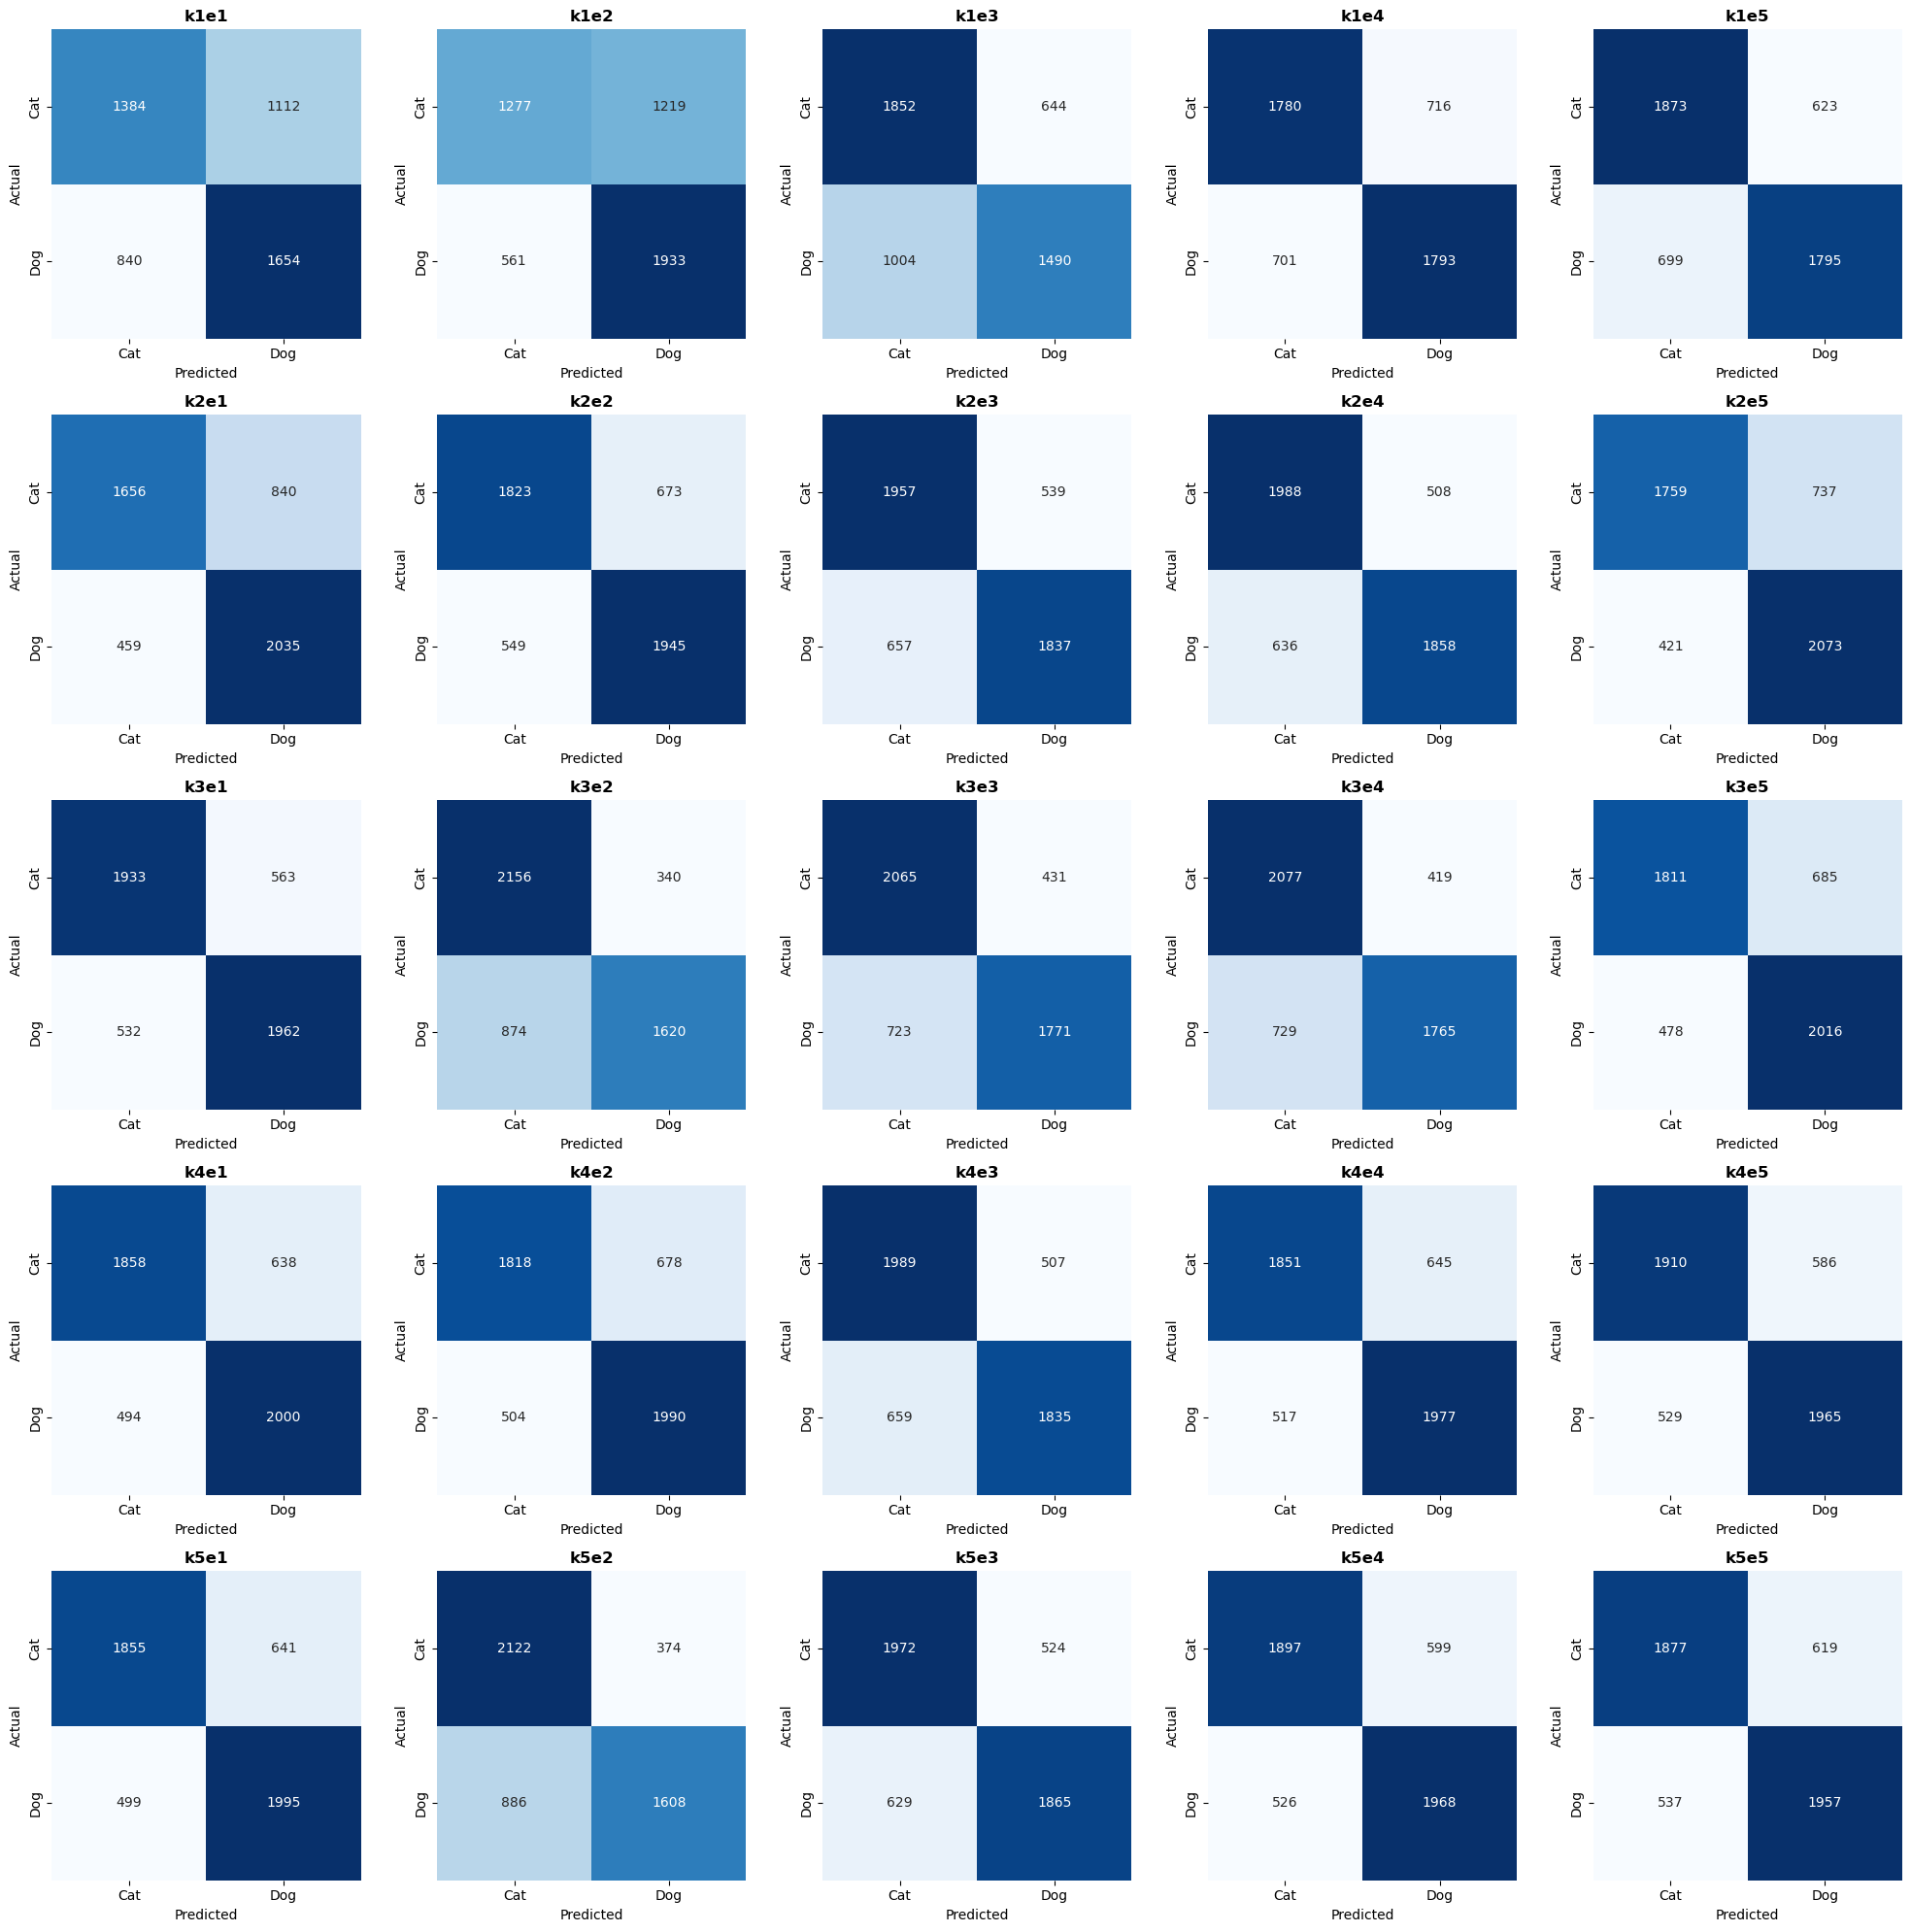

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def visualize_confusion_matrices(df, figsize=(20, 20)):
    """
    Visualize all confusion matrices in a grid.
    df: dataframe with 'model' and 'cm' columns
    """
    n_matrices = len(df)
    grid_size = int(np.ceil(np.sqrt(n_matrices)))  # Creates 5x5 grid for 25 items
    
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten()  # Flatten for easier iteration
    
    for idx, (_, row) in enumerate(df.iterrows()):
        ax = axes[idx]
        cm = np.array(row['cm'])
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                   cbar=False, square=True, annot_kws={'size': 10})
        
        ax.set_title(f"{row['model']}", fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_xticklabels(['Cat', 'Dog'])
        ax.set_yticklabels(['Cat', 'Dog'])
    
    # Hide unused subplots
    for idx in range(n_matrices, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# Call it
visualize_confusion_matrices(test_df)